## 12.12 神经风格迁移


### 环境配置


In [3]:
import os, sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "1"
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    import pypto
    import torch
    import torch_npu
    import torchvision
    from torch import nn
    from torch.nn import functional as F
    from src.D2LFunction import *

import logging
# pypto 导入会把根 logger 调到 DEBUG，压回 WARNING 避免刷屏
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"


---


### 练习 12.12.1

**题目：** 选择不同的内容和风格层，输出有什么变化？

**解答：**

&emsp;&emsp;一般来说，越靠近输入层，越容易抽取图像的细节信息；反之，越容易抽取图像的全局信息。将风格层选得更靠近输入层（如`style_layers = [0, 4, 9, 18, 28]`，内容层为`[26]`），合成的图像会保留更多纹理细节；将内容层选得更靠近输出层，内容保留更全局、更清晰。

以下使用 `torch` 编程进行验证：


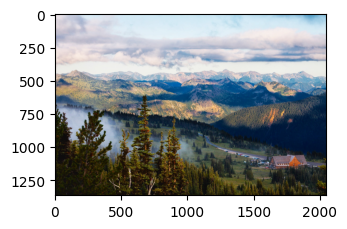

In [6]:
set_figsize()
content_img = Image.open('../../img/rainier.jpg')
plt.imshow(content_img);

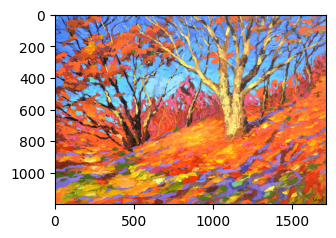

In [7]:
style_img = Image.open('../../img/autumn-oak.jpg')
plt.imshow(style_img);

In [8]:
# 预处理与后处理
rgb_mean = torch.tensor([0.485, 0.456, 0.406])
rgb_std = torch.tensor([0.229, 0.224, 0.225])

def preprocess(img, image_shape):
    transforms = torchvision.transforms.Compose([
        torchvision.transforms.Resize(image_shape),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean=rgb_mean, std=rgb_std)])
    return transforms(img).unsqueeze(0)

def postprocess(img):
    img = img[0].to(rgb_std.device)
    img = torch.clamp(img.permute(1, 2, 0) * rgb_std + rgb_mean, 0, 1)
    return torchvision.transforms.ToPILImage()(img.permute(2, 0, 1))

# 特征提取
def extract_features(X, content_layers, style_layers):
    contents, styles = [], []
    for i in range(len(net)):
        X = net[i](X)
        if i in style_layers:
            styles.append(X)
        if i in content_layers:
            contents.append(X)
    return contents, styles

def get_contents(image_shape, device):
    content_X = preprocess(content_img, image_shape).to(device)
    contents_Y, _ = extract_features(content_X, content_layers, style_layers)
    return content_X, contents_Y

def get_styles(image_shape, device):
    style_X = preprocess(style_img, image_shape).to(device)
    _, styles_Y = extract_features(style_X, content_layers, style_layers)
    return style_X, styles_Y

# 损失函数
def content_loss(Y_hat, Y):
    return torch.square(Y_hat - Y.detach()).mean()

def gram(X):
    num_channels, n = X.shape[1], X.numel() // X.shape[1]
    X = X.reshape((num_channels, n))
    return torch.matmul(X, X.T) / (num_channels * n)

def style_loss(Y_hat, gram_Y):
    return torch.square(gram(Y_hat) - gram_Y.detach()).mean()

def tv_loss(Y_hat):
    return 0.5 * (torch.abs(Y_hat[:, :, 1:, :] - Y_hat[:, :, :-1, :]).mean() +
                  torch.abs(Y_hat[:, :, :, 1:] - Y_hat[:, :, :, :-1]).mean())

def compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram):
    contents_l = [content_loss(Y_hat, Y) * content_weight for Y_hat, Y in zip(contents_Y_hat, contents_Y)]
    styles_l = [style_loss(Y_hat, Y) * style_weight for Y_hat, Y in zip(styles_Y_hat, styles_Y_gram)]
    tv_l = tv_loss(X) * tv_weight
    l = sum(10 * styles_l + contents_l + [tv_l])
    return contents_l, styles_l, tv_l, l

class SynthesizedImage(nn.Module):
    def __init__(self, img_shape, **kwargs):
        super().__init__(**kwargs)
        self.weight = nn.Parameter(torch.rand(*img_shape))

    def forward(self):
        return self.weight

def get_inits(X, device, lr, styles_Y):
    gen_img = SynthesizedImage(X.shape).to(device)
    gen_img.weight.data.copy_(X.data)
    trainer = torch.optim.Adam(gen_img.parameters(), lr=lr)
    styles_Y_gram = [gram(Y) for Y in styles_Y]
    return gen_img(), styles_Y_gram, trainer

def train(X, contents_Y, styles_Y, device, lr, num_epochs, lr_decay_epoch):
    X, styles_Y_gram, trainer = get_inits(X, device, lr, styles_Y)
    scheduler = torch.optim.lr_scheduler.StepLR(trainer, lr_decay_epoch, 0.8)
    for epoch in range(num_epochs):
        trainer.zero_grad()
        X = X.requires_grad_()
        contents_Y_hat, styles_Y_hat = extract_features(X, content_layers, style_layers)
        _, _, _, l = compute_loss(X, contents_Y_hat, styles_Y_hat, contents_Y, styles_Y_gram)
        l.backward()
        trainer.step()
        scheduler.step()
        if (epoch + 1) % 100 == 0:
            print(f'epoch {epoch + 1}: loss {l.item():.3f}')
    return X

In [9]:
# 更换风格层与内容层（风格层更靠近输入层，内容层更靠近输出层）
pretrained_net = torchvision.models.vgg19(pretrained=True)
style_layers, content_layers = [0, 4, 9, 18, 28], [26]
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])

content_weight, style_weight, tv_weight = 1, 1e3, 10

image_shape = (300, 450)
net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/buildtools/Python-3.11.4/lib/python3.11/site-packages/torch/autograd/__init__.py:221: UserWarning: Cannot create tensor with interal format while allow_internel_format=False, tensor will be created with base format. (Triggered internally at ../torch_npu/csrc/aten/common/TensorFactories.cpp:340.)
  torch.ones_like(out, memory_format=torch.

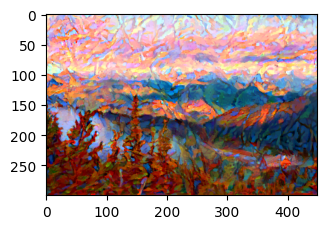

In [10]:
# 展示合成图像（与正文默认层组合的对比见主 notebook）
plt.imshow(postprocess(output));

&emsp;&emsp;风格层更靠近输入层时，合成图像会保留更多的纹理细节；内容层更靠近输出层时，图像中的内容更加清晰。

---


### 练习 12.12.2

**题目：** 调整损失函数中的权重超参数。输出是否保留更多内容或减少更多噪点？

**解答：**

&emsp;&emsp;风格迁移的总损失是内容损失、风格损失和全变分损失的加权和。将权重从`[1, 1e3, 10]`改为`[1e3, 1, 10]`（增大内容损失权重、减小风格损失权重）后，合成图像保留更多内容细节，但风格迁移效果减弱；反之增大风格权重、减小内容权重，图像更“风格化”但可能丢失内容并产生更多噪点。

以下使用 `torch` 编程进行验证（增大内容权重、减小风格权重）：


In [14]:
pretrained_net = torchvision.models.vgg19(pretrained=True)
style_layers, content_layers = [0, 5, 10, 19, 28], [25]
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])

content_weight, style_weight, tv_weight = 1e3, 1, 10

net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

epoch 100: loss 70.773
epoch 200: loss 44.806
epoch 300: loss 36.835
epoch 400: loss 33.324
epoch 500: loss 31.335


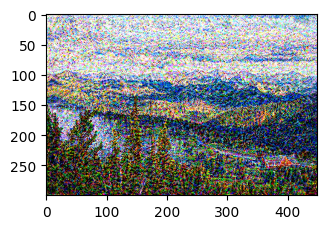

In [15]:
plt.imshow(postprocess(output));

&emsp;&emsp;对比正文的`[1, 1e3, 10]`，增大内容权重后合成图像保留了更多内容细节、噪点更少，但风格色彩相对减弱。

---


### 练习 12.12.3

**题目：** 替换实验中的内容图像和风格图像，能创作出更有趣的合成图像吗？

**解答：**

&emsp;&emsp;可以。更换内容图像与风格图像组合，可以创作出风格各异的合成图像，例如用书籍插画作为内容图像、秋日橡树作为风格图像。

以下使用 `torch` 编程进行验证（替换内容图像）：


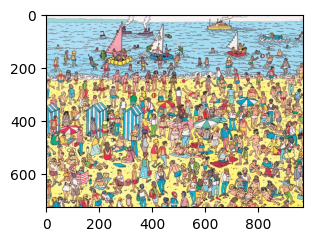

In [19]:
set_figsize()
content_img = Image.open('../../img/where-wally-walker-books.jpg')
plt.imshow(content_img);

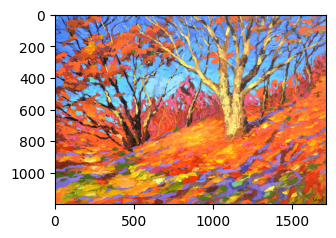

In [20]:
style_img = Image.open('../../img/autumn-oak.jpg')
plt.imshow(style_img);

In [21]:
pretrained_net = torchvision.models.vgg19(pretrained=True)
style_layers, content_layers = [0, 5, 10, 19, 28], [25]
net = nn.Sequential(*[pretrained_net.features[i] for i in
                      range(max(content_layers + style_layers) + 1)])

content_weight, style_weight, tv_weight = 1, 1e3, 10

net = net.to(device)
content_X, contents_Y = get_contents(image_shape, device)
_, styles_Y = get_styles(image_shape, device)
output = train(content_X, contents_Y, styles_Y, device, 0.3, 500, 50)

epoch 100: loss 6.667
epoch 200: loss 4.543
epoch 300: loss 3.934
epoch 400: loss 3.611
epoch 500: loss 3.479


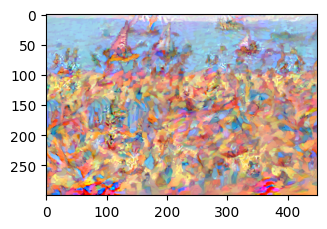

In [22]:
plt.imshow(postprocess(output));

&emsp;&emsp;更换内容图像后，合成图像保留了新内容图像的结构，并迁移了风格图像的色彩与笔触，效果更有趣。

使用 `PyPTO` 编程进行验证（风格迁移的风格损失以 Gram 矩阵 `X @ X^T` 为核心；12.10 节已验证 `PyPTOConv2DModule` 的 matmul kernel（`_matmul_bt_kernel`）可算任意 `A @ B^T`，这里直接用它计算风格特征的 Gram 矩阵，与 torch 逐值对比）：

In [25]:
# PyPTO 验证：Gram 矩阵用 PyPTO matmul kernel 计算（C = X @ X^T）
from src.PyPTOConv2DModule import _matmul_bt_kernel

def gram_pypto(X):
    num_channels, n = X.shape[1], X.numel() // X.shape[1]
    X2 = X.reshape(num_channels, n).contiguous()
    out = torch.zeros(num_channels, num_channels, device=X.device,
                      dtype=torch.float32)
    _matmul_bt_kernel(X2, X2, out)
    return out / (num_channels * n)

# 注：该 matmul kernel 对 ND 格式输入的 inner axis（n = H*W）限制 < 65535 字节，
# 即 n < 16384；首层特征 n=33750 超限，故用深层风格特征。
Xf = styles_Y[3].detach()                      # conv4_2 风格特征 (512 通道, n=2128)
g_torch = gram(Xf)
g_pypto = gram_pypto(Xf)
print('PyPTO Gram 矩阵与 torch 一致:', torch.allclose(g_pypto.cpu(), g_torch.cpu(),
                                                     atol=1e-5),
      '，maxdiff:', f'{(g_pypto - g_torch).abs().max().item():.2e}')

# 用 PyPTO Gram 计算风格损失（与练习 12.12.2 的权重调整同一公式）
target = gram(styles_Y[4].detach())  # conv5_2 风格特征（同为 512 通道）
l_pt = torch.square(g_pypto - target).mean()
l_tc = torch.square(g_torch - target).mean()
print('PyPTO Gram 风格损失与 torch 一致:', torch.allclose(l_pt.cpu(), l_tc.cpu(),
                                                         atol=1e-6))


PyPTO Gram 矩阵与 torch 一致: True ，maxdiff: 2.09e-07
PyPTO Gram 风格损失与 torch 一致: True


&emsp;&emsp;PyPTO Gram 矩阵与 torch 一致，风格损失亦一致——风格迁移计算链中的矩阵乘法环节可下沉 PyPTO matmul kernel（Cube/AIC），与 12.10 节转置卷积的 matmul 路线同源。注：该 kernel 单次调用的 inner axis（特征的行数 n = H×W）受 ND 格式 65535 字节限制（n < 16384），大特征需把 matmul 的 K 维拆分或改用深层小特征，代码中已注明。

---


### 练习 12.12.4

**题目：** 我们可以对文本使用风格迁移吗？提示:可以参阅调查报告。

**解答：**

&emsp;&emsp;可以。文本风格迁移是将给定文本的风格从一个样式（例如正式、非正式、文艺、幽默等）转移到另一个样式，在保留文本内容的基础上，通过编辑或生成的方式更改文本的特定风格或属性（如情感、时态、性别等）。它与图像风格迁移类似，但操作对象是文本序列而非图像像素：

- 早期方法使用模板/规则或机器翻译式的“风格翻译”思路；
- 深度学习方法通常基于预训练语言模型，通过对抗训练、强化学习或提示（Prompt）等方式解耦内容与风格；
- 代表性工作可参考文本风格迁移综述（如 Hu et al., 2020）。

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)
